# OFDM Multi-TX Channel Sounding

Authors: Meles Gebreyesus Weldegebriel and Neal Patwari
Version: Mar 2026. Version 0.1.

This code assumes that someone has done the following before you run this tutorial.
1. Generate a "channel sounding OFDM packet" (of all pilot channels) for transmission over SDRs
2. The packet is then transmitted over the air in POWDER using Shout-over-each-other using the given instructions.

In this notebook, we're going to run only the receiver, and estimate and plot the channel frequency responses (CFRs) for each receiver (from each transmitter)

This code  allows you to:
1. Load the received data from file.
2. Synchronize to the OFDM packet.
3. Take the FFT of each symbol to get the subchannel (complex) values
4. Use the known transmitted complex subchannel pilot values to compute the channel gain in magnitude and phase
5. Plot the CFR and CIR in different ways: over the `repetitions` symbols,  over frequency (the pilot subchannels), and on average over all repetitions.

In [ ]:
import os
import random
import glob
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import h5py
import datetime
import scipy.io
import scipy.signal as signal
from itertools import chain
from scipy.signal import correlate, correlation_lags, fftconvolve
from matplotlib import rc
rc('xtick', labelsize=14)
rc('ytick', labelsize=14)

## 1. Load the received data from file.

In [ ]:
load_from_github = False

# # Load in files from the github repo for this tutorial.
if load_from_github:
  user = "npatwari"
  repo = "ch-sounding-ofdm-packet"
  # remove local directory if it already exists
  if os.path.isdir(repo):
    !rm -rf {repo}
else:
  # user must upload the zip file to the working directory.
  datestr = "04-09-2026_12-09-38"
  zipfile = "/content/Shout_meas_" + datestr + ".zip"
  !unzip -o {zipfile}
  data_dir = os.path.splitext(zipfile)[0]
  print("data_dir = " + data_dir)


# !git clone https://github.com/{user}/{repo}.git

Archive:  /content/Shout_meas_04-09-2026_12-09-38.zip
   creating: Shout_meas_04-09-2026_12-09-38/
  inflating: Shout_meas_04-09-2026_12-09-38/log  
  inflating: Shout_meas_04-09-2026_12-09-38/save_iq_w_tx_file.json  
  inflating: Shout_meas_04-09-2026_12-09-38/measurements.hdf5  
data_dir = /content/Shout_meas_04-09-2026_12-09-38


In [ ]:
pilotsfile = "/content/channel-sounding-set-64pilots.zip"
!unzip -o {pilotsfile}
pilots_dir = os.path.splitext(pilotsfile)[0]
print("data_dir = " + pilots_dir)

# Initialize empty arrays
pilotValues = {}
norm_ofdm_time = {}
eps = 1e-5
for npz_filename in glob.glob(pilots_dir + '/pilot-info-27-03-26*.npz'):

  # Pull just the string after the final "-" in the filename to get the "name" of that npz file to use here.
  filecode = npz_filename.split("-")[-1].split(".")[0]
  print("Loading from " + npz_filename + " Filecode " + filecode)

  # Load the file and get the OFDM_vals and the norm_ofdm_time into a dictionary of such arrays
  with np.load(npz_filename) as temp:
    # I'm assuming some of these things are not necessary to save for each file.
    OFDM_vals = temp["data"]
    norm_ofdm_time[filecode] = temp["norm_ofdm_time"]
    repetitions = temp['repetitions']
    pilotCarriers = np.where(np.abs(OFDM_vals) > eps)
    pilotValues[filecode] = OFDM_vals[pilotCarriers]
    FFT_size = len(OFDM_vals)
    pilots = len(pilotValues)

# Convert pilotValues.keys() into a list
keys_list = list(pilotValues.keys())
print(keys_list)


Archive:  /content/channel-sounding-set-64pilots.zip
  inflating: channel-sounding-set-64pilots/channel-sounding-OFDM-packet-27-03-26-c.iq  
  inflating: __MACOSX/channel-sounding-set-64pilots/._channel-sounding-OFDM-packet-27-03-26-c.iq  
  inflating: channel-sounding-set-64pilots/channel-sounding-one-symbol-27-03-26-d.iq  
  inflating: __MACOSX/channel-sounding-set-64pilots/._channel-sounding-one-symbol-27-03-26-d.iq  
  inflating: channel-sounding-set-64pilots/channel-sounding-one-symbol-27-03-26-e.iq  
  inflating: __MACOSX/channel-sounding-set-64pilots/._channel-sounding-one-symbol-27-03-26-e.iq  
  inflating: channel-sounding-set-64pilots/channel-sounding-OFDM-packet-27-03-26-f.iq  
  inflating: __MACOSX/channel-sounding-set-64pilots/._channel-sounding-OFDM-packet-27-03-26-f.iq  
  inflating: channel-sounding-set-64pilots/.DS_Store  
  inflating: __MACOSX/channel-sounding-set-64pilots/._.DS_Store  
  inflating: channel-sounding-set-64pilots/channel-sounding-one-symbol-27-03-26-a.

Our simple OFDM packet structure is simply many repetitions of the same all-pilot OFDM symbol.





Here, we load the rx signal from a previously conducted OTA experiment file.

In [ ]:
def get_time_string(timestamp):
    '''
    Helper function to get data and time from timestamp
    INPUT: timestamp
    OUTPUT: data and time. Example: 01-04-2023, 19:50:27
    '''
    date_time = datetime.datetime.fromtimestamp(int(timestamp))
    return date_time.strftime("%m-%d-%Y, %H:%M:%S")

def JsonLoad(folder, json_file):
    '''
    Load parameters from the saved json file
    INPUT
    ----
        folder: path to the measurement folder. Example: "SHOUT/Results/Shout_meas_01-04-2023_18-50-26"
        json_file: the json file with all the specifications. Example: '/save_iq_w_tx_gold.json'
    OUTPUT
    ----
        samps_per_chip: samples per chip
        wotxrepeat: number of repeating IQ sample collection w/o transmission. Used as an input to
        traverse_dataset() func
        rxrate: sampling rate at the receiver side
    '''
    config_file = folder+'/'+json_file
    config_dict = json.load(open(config_file))[0]
    nsamps = config_dict['nsamps']
    rxrate = config_dict['rxrate']
    rxfreq = config_dict['rxfreq']
    wotxrepeat = config_dict['wotxrepeat']
    rxrepeat = config_dict['rxrepeat']
    txnodes = config_dict['txclients']
    rxnodes = config_dict['rxclients']

    return rxrepeat, rxrate, txnodes, rxnodes, nsamps

def traverse_dataset(meas_folder):
    '''
    Load data from hdf5 format measurement file
    INPUT
    ----
        meas_folder: path to the measurement folder. Example: "SHOUT/Results/Shout_meas_01-04-2023_18-50-26"
    OUTPUT
    ----
        data: Collected IQ samples w/ transmission. It is indexed by the transmitter name
        noise: Collected IQ samples w/o transmission. It is indexed by the transmitter name
        txrxloc: transmitter and receiver names
    '''
    data = {}
    noise = {}
    txrxloc = {}

    dataset = h5py.File(meas_folder + '/measurements.hdf5', "r") #meas_folder
    print("Dataset meta data:", list(dataset.attrs.items()))
    for cmd in dataset.keys():
        print("Command:", cmd)
        if cmd == 'saveiq':
            cmd_time = list(dataset[cmd].keys())[0]
            print("  Timestamp:", get_time_string(cmd_time))
            print("  Command meta data:", list(dataset[cmd][cmd_time].attrs.items()))
            for rx_gain in dataset[cmd][cmd_time].keys():
                print("   RX gain:", rx_gain)
                for rx in dataset[cmd][cmd_time][rx_gain].keys():
                    print("     RX:", rx)
                    print("       Measurement items:", list(dataset[cmd][cmd_time][rx_gain][rx].keys()))
        elif cmd == 'saveiq_w_tx':
            cmd_time = list(dataset[cmd].keys())[0]
            print("  Timestamp:", get_time_string(cmd_time))
            print("  Command meta data:", list(dataset[cmd][cmd_time].attrs.items()))
            for tx in dataset[cmd][cmd_time].keys():
                print("   TX:", tx)

                if tx == 'wo_tx':
                    for rx_gain in dataset[cmd][cmd_time][tx].keys():
                        print("       RX gain:", rx_gain)
                        #print(dataset[cmd][cmd_time][tx][rx_gain].keys())
                        for rx in dataset[cmd][cmd_time][tx][rx_gain].keys():
                            print("         RX:", rx)
                            #print("           Measurement items:", list(dataset[cmd][cmd_time][tx][rx_gain][rx].keys()))
                            repeat = np.shape(dataset[cmd][cmd_time][tx][rx_gain][rx]['rxsamples'])[0]
                            print("         repeat", repeat)

                            samplesNotx =  dataset[cmd][cmd_time][tx][rx_gain][rx]['rxsamples'][:repeat, :]
                            namelist = rx.split('-')
                            noise[namelist[1]] = samplesNotx
                else:
                    for tx_gain in dataset[cmd][cmd_time][tx].keys():
                        print("     TX gain:", tx_gain)
                        for rx_gain in dataset[cmd][cmd_time][tx][tx_gain].keys():
                            print("       RX gain:", rx_gain)
                            #print(dataset[cmd][cmd_time][tx][tx_gain][rx_gain].keys())
                            for rx in dataset[cmd][cmd_time][tx][tx_gain][rx_gain].keys():
                                repeat = np.shape(dataset[cmd][cmd_time][tx][tx_gain][rx_gain][rx]['rxsamples'])[0]
                                print("         RX:", rx, "; samples shape", np.shape(dataset[cmd][cmd_time][tx][tx_gain][rx_gain][rx]['rxsamples']))
                                #print("         Measurement items:", list(dataset[cmd][cmd_time][tx][tx_gain][rx_gain][rx].keys()))
                                # print("         rxloc", (dataset[cmd][cmd_time][tx][tx_gain][rx_gain][rx]['rxloc'][0]))
                                # peak avg check
                                txrxloc.setdefault(tx, []).extend([rx]*repeat)
                                rxsamples = dataset[cmd][cmd_time][tx][tx_gain][rx_gain][rx]['rxsamples'][:repeat, :]
                                data.setdefault(tx, []).append(np.array(rxsamples))

        else:
            print('Unsupported command: ', cmd)

    return data, noise, txrxloc

In [ ]:
rx_data, noise, txrxloc = traverse_dataset(data_dir)

numTxCombos = len(rx_data)
print("Number of Tx combos: " + str(numTxCombos))

jsonfile = "save_iq_w_tx_file.json"
rxrepeat, samp_rate, txlocs, rxlocs, nsamps = JsonLoad(data_dir, jsonfile)
print("rxrepeat: " + str(rxrepeat))
print("samp_rate: " + str(samp_rate))
print("txlocs: " + str(txlocs))
print("rxlocs: " + str(rxlocs))

t = np.arange(0, nsamps)/samp_rate


Dataset meta data: [('shout_version', '495923e')]
Command: saveiq_w_tx
  Timestamp: 04-09-2026, 18:09:40
  Command meta data: [('cmd', 'save_iq_w_tx'), ('nsamps', np.int64(8192)), ('rxfreq', np.float64(3390000000.0)), ('rxgain', np.float64(70.0)), ('rxrate', np.float64(5000000.0)), ('rxrepeat', np.int64(4)), ('rxwait_max', np.int64(2000)), ('rxwait_min', np.int64(50)), ('rxwait_random', np.True_), ('rxwait_res', 'ms'), ('start_time', np.float64(1775758186.0)), ('sync', np.True_), ('timeout', np.int64(30)), ('timezone', 'US/Mountain'), ('txfile', '/local/repository/shout/signal_library/ofdm.iq'), ('txfreq', np.float64(3390000000.0)), ('txgain', np.float64(80.0)), ('txrate', np.float64(5000000.0)), ('txwait', np.int64(3)), ('use_lo_offset', np.True_), ('wotxrepeat', np.int64(1))]
   TX: 0
     TX gain: 80.0
       RX gain: 70.0
         RX: cnode-ebc-dd-b210 ; samples shape (4, 8192)
         RX: cnode-guesthouse-dd-b210 ; samples shape (4, 8192)
         RX: cnode-mario-dd-b210 ; sample

Plot the frequency domain representation of the received signal to "see" that the signal was transmitted and received correctly.

Tx: 0
Tx: 0+cnode-ebc-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-ustar-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210


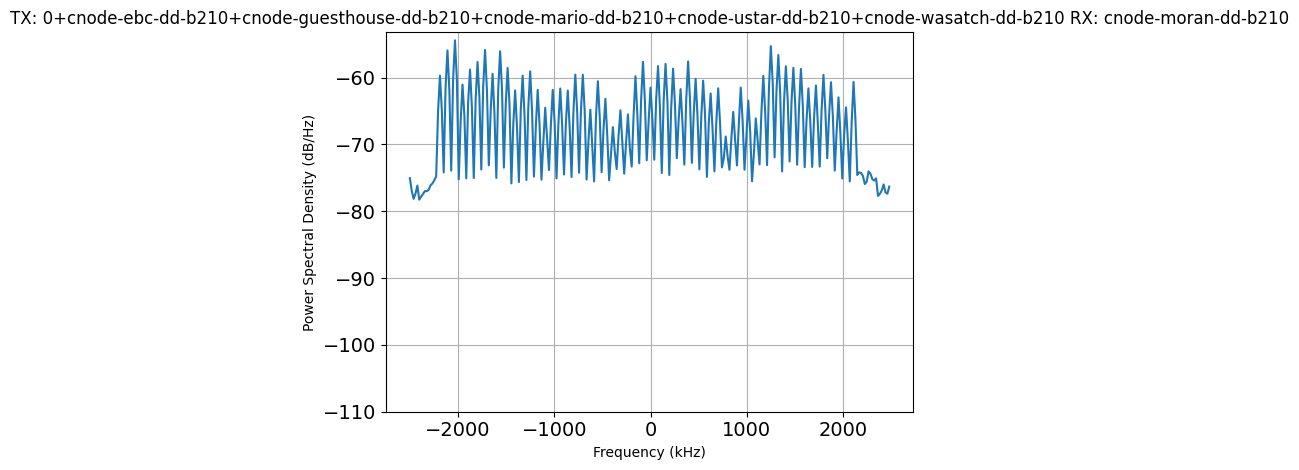

Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-moran-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-moran-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-ustar-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-mario-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210


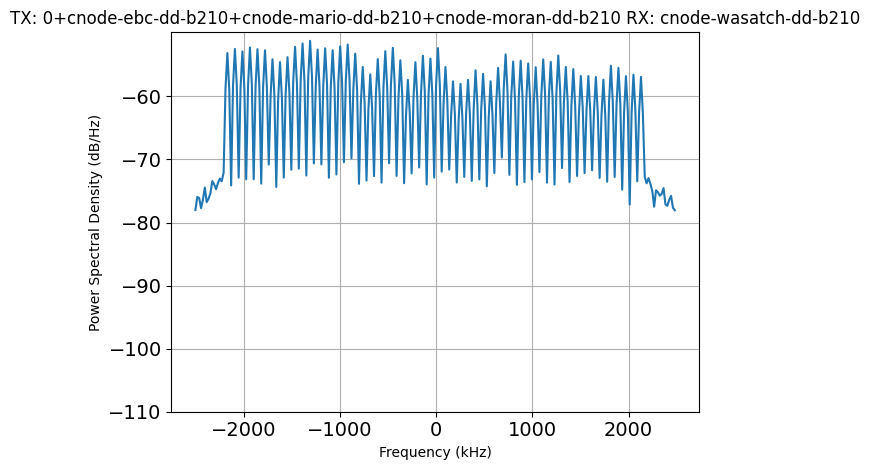

Tx: 0+cnode-ebc-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-mario-dd-b210+cnode-ustar-dd-b210


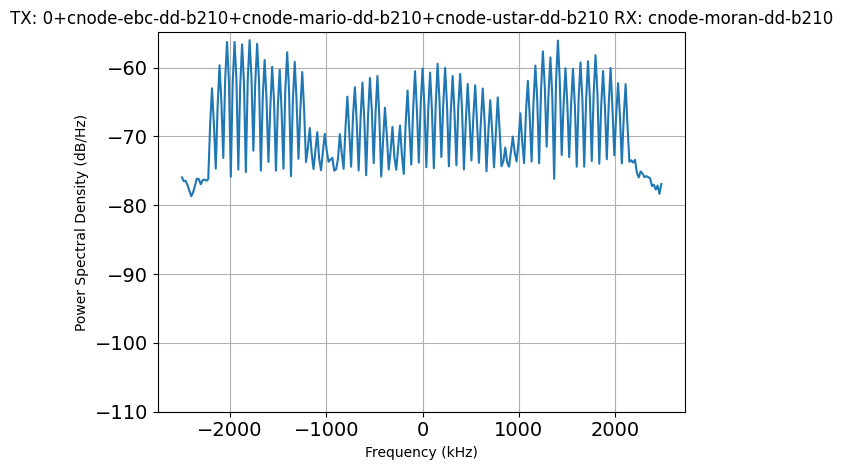

Tx: 0+cnode-ebc-dd-b210+cnode-mario-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-mario-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-moran-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-moran-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-ustar-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ebc-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-guesthouse-dd-b210


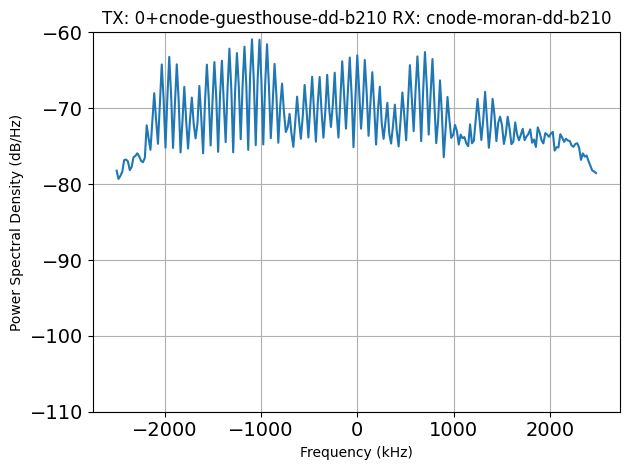

Tx: 0+cnode-guesthouse-dd-b210+cnode-mario-dd-b210
Tx: 0+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210
Tx: 0+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210
Tx: 0+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-ustar-dd-b210
Tx: 0+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-guesthouse-dd-b210+cnode-moran-dd-b210
Tx: 0+cnode-guesthouse-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210
Tx: 0+cnode-guesthouse-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-guesthouse-dd-b210+cnode-moran-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-guesthouse-dd-b210+cnode-ustar-dd-b210


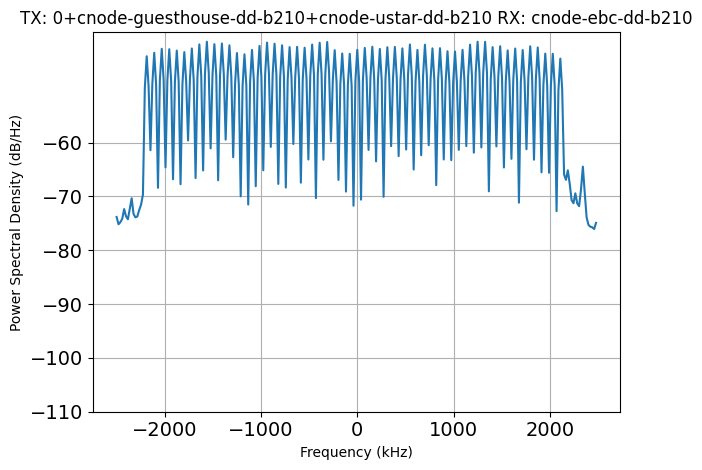

Tx: 0+cnode-guesthouse-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-guesthouse-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-mario-dd-b210


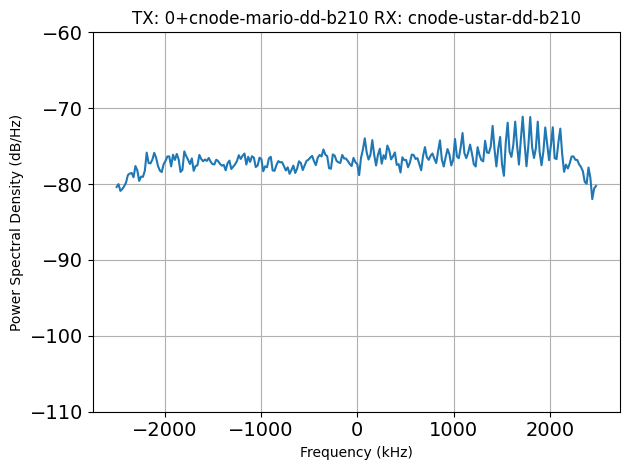

Tx: 0+cnode-mario-dd-b210+cnode-moran-dd-b210
Tx: 0+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210
Tx: 0+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-mario-dd-b210+cnode-ustar-dd-b210


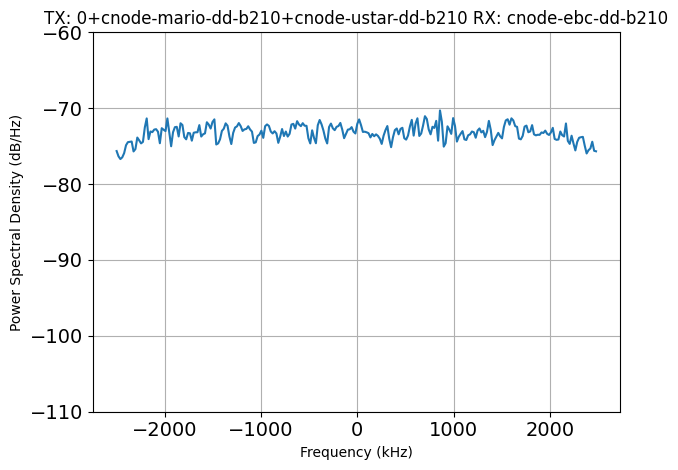

Tx: 0+cnode-mario-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-mario-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-moran-dd-b210
Tx: 0+cnode-moran-dd-b210+cnode-ustar-dd-b210
Tx: 0+cnode-moran-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210


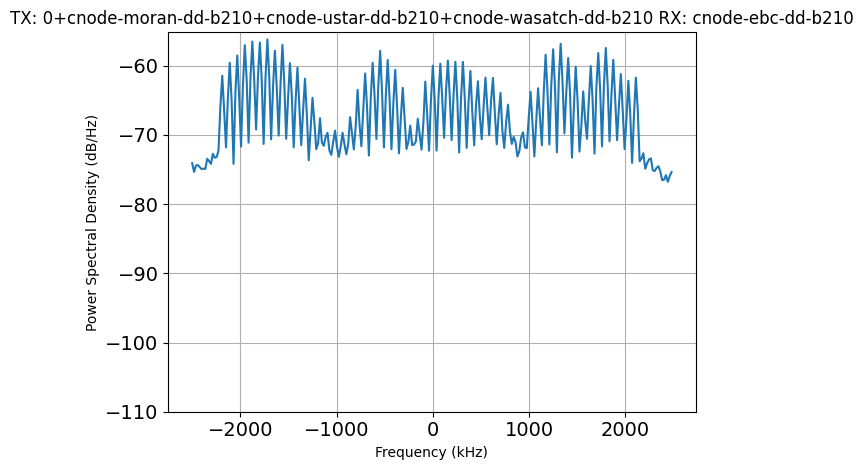

Tx: 0+cnode-moran-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-ustar-dd-b210
Tx: 0+cnode-ustar-dd-b210+cnode-wasatch-dd-b210
Tx: 0+cnode-wasatch-dd-b210


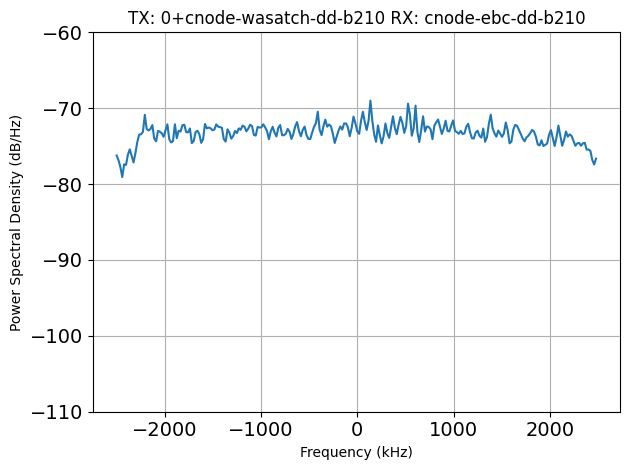

In [ ]:
def plotOnePSDForEachLink(rx_data, txrxloc, samp_rate, repeats, repNum, prob):
    for txname in rx_data:
        print("Tx: " + txname)
        for i in range(0, len(rx_data[txname])):
            x = random.random()
            if x < prob:
                plt.figure()
                # This code arbitrarily picks the 0 rep to plot.
                plt.psd(rx_data[txname][i][repNum], Fs = samp_rate/1000)

                ylimits = [-110, -50]
                #plt.ylim(ylimits)
                plt.yticks(range(ylimits[0], ylimits[1],10))

                plt.grid('on')
                recordNum = i*repeats + repNum
                plt.title('TX: {} RX: {}'.format(txname, txrxloc[txname][recordNum]))
                plt.xlabel('Frequency (kHz)')
                plt.tight_layout()
                plt.show()


# Plot all links, but just the data from the 0th repetition
# To change the repetition number, add repNum=n for n in the range 0 to the
# total number of repetitions -1.
plotOnePSDForEachLink(rx_data, txrxloc, samp_rate, rxrepeat, repNum=0, prob=0.05)

In [ ]:
# Pick one received signal to work on
#txloc = '0+cnode-mario-dd-b210+cnode-moran-dd-b210' # eg.,
txloc = '0+cnode-ebc-dd-b210'
rxloc = 'cnode-ustar-dd-b210' # eg., 'cbrssdr1-meb-comp'
repNum = 1 # eg., 0
# print(rx_data[txloc])

rx_data[txloc] = np.vstack(rx_data[txloc])
rxloc_arr = np.array(txrxloc[txloc])
rx0 = rx_data[txloc][rxloc_arr==rxloc][repNum]
print('\nLink: {} to {}. Repetition Num {}.'.format(txloc, rxloc, repNum))
rx0.shape

# I assigned in my experiment with transmitters using particular files.
#scp /Users/neal/git/npatwari/shout-over-each-other/channel-sounding-set-64pilots/channel-sounding-OFDM-packet-27-03-26-a.iq npatwari@cnode-ebc.emulab.net:/local/repository/shout/signal_library/ofdm.iq
#scp /Users/neal/git/npatwari/shout-over-each-other/channel-sounding-set-64pilots/channel-sounding-OFDM-packet-27-03-26-b.iq npatwari@cnode-guesthouse.emulab.net:/local/repository/shout/signal_library/ofdm.iq
#scp /Users/neal/git/npatwari/shout-over-each-other/channel-sounding-set-64pilots/channel-sounding-OFDM-packet-27-03-26-c.iq npatwari@cnode-mario.emulab.net:/local/repository/shout/signal_library/ofdm.iq
#scp /Users/neal/git/npatwari/shout-over-each-other/channel-sounding-set-64pilots/channel-sounding-OFDM-packet-27-03-26-d.iq npatwari@cnode-moran.emulab.net:/local/repository/shout/signal_library/ofdm.iq
#scp /Users/neal/git/npatwari/shout-over-each-other/channel-sounding-set-64pilots/channel-sounding-OFDM-packet-27-03-26-e.iq npatwari@cnode-ustar.emulab.net:/local/repository/shout/signal_library/ofdm.iq
# So here I make a dictionary



Link: 0+cnode-ebc-dd-b210 to cnode-ustar-dd-b210. Repetition Num 1.


(8192,)

In [ ]:
def convert_txname_to_int(txname, txlocs):

  # Convert txname to a binary array, y. Element i, y[i]==1 if txname contains the string txlocs[i].
  # Convert binary array y to a decimal value, first element is the most-significant bit
  numnodes = len(txlocs)
  txgroup_num = 0
  txes_in_group = 0
  for i in range(numnodes):
    if (txlocs[i] in txname):
      txgroup_num += 2**((numnodes-1) - i)
      txes_in_group += 1

  return txgroup_num, txes_in_group

# Test code for the convert_txname_to_int() function
#txloc = '0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210'
#txloc = '0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210+cnode-wasatch-dd-b210'
#print('txloc =', txloc)
#print('Converts to integer ', str(convert_txname_to_int(txloc, txlocs)))

In [ ]:
def convert_int_to_tflist(txgroup_num, txlocs):

  # Init the return vector
  tflist = np.empty(len(txlocs), dtype=np.int8)

  # Convert the decimal integer txgroup_num to binary string, length txlocs
  # tflist[i] == True if that node is TXing, according to txgroup_num
  b = format(txgroup_num, str(len(txlocs)) + 'b')
  for i, char in enumerate(b):
    tflist[i] = (char == '1')

  return tflist

In [ ]:
print(convert_int_to_tflist(5, txlocs))

[0 0 0 1 0 1]


In [ ]:
def calcPowerTXOn(rx0, num_clusters=2, plot_option=False):

  instantaneous_power = np.real(np.multiply(rx0, np.conjugate(rx0)))

  # otherwise: compute a windowed average power over all `window_len` sample-length windows
  # These should be non-overlapping
  window_len = 400
  wl2 = window_len//2
  samples = len(instantaneous_power)
  window_centers = range(wl2, samples-wl2, window_len)
  partition_avg_power = np.zeros(len(window_centers))
  #print(window_centers)
  for j,i in enumerate(window_centers):
    partition_avg_power[j] = np.average( instantaneous_power[i-wl2:i+wl2] )


  # if num_clusters <= 1, then make high_power_avg_power low_power_avg_power
  # both equal to the average of all partition_avg_power
  if num_clusters <= 1:
    high_power_avg_power = np.mean(partition_avg_power)
    low_power_avg_power = high_power_avg_power

  else:
    # Return the high and the low average power.
    # Sort returns values in increasing order, so highest is in [-1] index
    centers_sorted = np.sort(partition_avg_power)
    high_power_avg_power = centers_sorted[-1]
    low_power_avg_power = centers_sorted[0]

  # Output figure and cluster values if requested
  if plot_option:
    time_ms = t*1000
    plt.figure()
    plt.plot(time_ms, instantaneous_power, 'k.', label=r'$|x|^2$')
    plt.plot(time_ms[window_centers], partition_avg_power, 'r-o', label="Avg Power")
    plt.plot([time_ms[0], time_ms[-1]], [high_power_avg_power, high_power_avg_power], 'c-', label='High Power')
    plt.xlabel('Time (ms)', fontsize=14)
    plt.ylabel('Normalized Power', fontsize=14)
    plt.tight_layout()
    plt.legend(loc='upper right', fontsize=14)
    plt.grid('on')

  return high_power_avg_power, low_power_avg_power

In [ ]:
# Create a data structure for the received power measurements.
# This will be a list of dictionaries.
# The list will be indexed by txgroup_num, an integer that represents the list of transmitters that are simultaneously TXing.
# - Consider that each node can be be a tx, or not. So listing the names in alphabetical order, there is a num_nodes-length
#   list of binary numbers. txgroup_num is the decimal equivalent of that binary list, with the first binary number is the MSB
# - So total_power[i] for a decimal number i references all received power measurmeents when tx group i (but in binary) is transmitting.
# The total_power[i] references a dictionary: total_power[i][receiver_name] is the received power measured at receiver_name,
# - receiver_name is a string. The value output is a list of real-valued power measurements.
# - total_power[i][receiver_name][j] is the jth measurement. There are rxrepeat measurements per receiver.
# - The real-valued power measurement is averaged over the period of the overlap of all transmissions
total_power = [dict() for i in range(numTxCombos)]
plot_option = False
for txname in rx_data:
  txgroup_num, txes_in_group = convert_txname_to_int(txname, txlocs)
  print(str(txes_in_group) + "Tx: " + txname)
  rxloc_arr = np.array(txrxloc[txname])
  unique_rx_names = rxloc_arr[range(0,len(rxloc_arr),rxrepeat)]
  rx_data[txname] = np.vstack(rx_data[txname])

  for rx_index, rx in enumerate(unique_rx_names):
    print(str(txgroup_num) + ' ' + rx)
    # Create a blank list of the total received power measurements for this receiver
    total_power[txgroup_num][rx] = np.zeros(rxrepeat)
    for i in range(0, rxrepeat):
      recordNum = rx_index*rxrepeat + i
      rx0 = rx_data[txname][recordNum]
      # Calculate the received power during the period in which all TXs are simultaneously transmitting
      # Then store it in the total_power data structure.
      hpap, lpap = calcPowerTXOn(rx0, txes_in_group+1, plot_option)
      total_power[txgroup_num][rx][i] = hpap

      if plot_option:
        #plt.title('RX: {}, RxPower(High): {}'.format(rxloc_arr[recordNum], str(hpap)))
        plt.title('RX: {}'.format(rxloc_arr[recordNum]))
        print(rxloc_arr[recordNum])
        plt.show()


0Tx: 0
0 cnode-ebc-dd-b210
0 cnode-guesthouse-dd-b210
0 cnode-mario-dd-b210
0 cnode-moran-dd-b210
0 cnode-ustar-dd-b210
0 cnode-wasatch-dd-b210
1Tx: 0+cnode-ebc-dd-b210
32 cnode-guesthouse-dd-b210
32 cnode-mario-dd-b210
32 cnode-moran-dd-b210
32 cnode-ustar-dd-b210
32 cnode-wasatch-dd-b210
2Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210
48 cnode-mario-dd-b210
48 cnode-moran-dd-b210
48 cnode-ustar-dd-b210
48 cnode-wasatch-dd-b210
3Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210
56 cnode-moran-dd-b210
56 cnode-ustar-dd-b210
56 cnode-wasatch-dd-b210
4Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210
60 cnode-ustar-dd-b210
60 cnode-wasatch-dd-b210
5Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-ustar-dd-b210
62 cnode-wasatch-dd-b210
5Tx: 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210+cnode-wasatch-dd-b210
61 cnode-ustar-dd-b210
4Tx: 0+cnode-ebc

In [ ]:
for rx in total_power[50]:
  print(rx)
  print(total_power[50][rx])

cnode-mario-dd-b210
[0.00021538 0.00038671 0.00021684 0.00045779]
cnode-moran-dd-b210
[0.00238463 0.0046507  0.002021   0.00558749]
cnode-wasatch-dd-b210
[0.00026549 0.00027446 0.00325466 0.00026193]


In [ ]:
np.median(total_power[32]['cnode-guesthouse-dd-b210'])

np.float64(0.18455088883638382)

In [ ]:
# Make a 2D array of all average received powers when there is one transmitter operating

# Initialize a 2D dictionary with entries for each (TX, RX) pair
single_tx_power = dict()
for txname in txlocs:
  single_tx_power[txname] = dict()
  # Find the group number for the "set" of just-this-transmitter
  tx_str = "0+" + txname
  tx_groupnum, junk = convert_txname_to_int(tx_str, txlocs)
  print(tx_str + " " + str(tx_groupnum))
  for rxname in txlocs:
    # Grab the total_power for this txgroupnum and for this rxname
    # As long as rxname is not equal to txname
    # save it into a the 2D array
    if rxname in total_power[tx_groupnum]:
      temp = np.average(total_power[tx_groupnum][rxname])
    else:
      temp = -999 # Code for not measured
    single_tx_power[txname][rxname] = temp

print(single_tx_power)

0+cnode-ebc-dd-b210 32
0+cnode-guesthouse-dd-b210 16
0+cnode-mario-dd-b210 8
0+cnode-moran-dd-b210 4
0+cnode-ustar-dd-b210 2
0+cnode-wasatch-dd-b210 1
{'cnode-ebc-dd-b210': {'cnode-ebc-dd-b210': -999, 'cnode-guesthouse-dd-b210': np.float64(0.18663474917411804), 'cnode-mario-dd-b210': np.float64(0.00019769436039496213), 'cnode-moran-dd-b210': np.float64(0.0019227535522077233), 'cnode-ustar-dd-b210': np.float64(0.00682646909262985), 'cnode-wasatch-dd-b210': np.float64(0.0002827141506713815)}, 'cnode-guesthouse-dd-b210': {'cnode-ebc-dd-b210': np.float64(0.10802592675463529), 'cnode-guesthouse-dd-b210': -999, 'cnode-mario-dd-b210': np.float64(0.00017110285989474505), 'cnode-moran-dd-b210': np.float64(0.0005236824799794704), 'cnode-ustar-dd-b210': np.float64(0.00023443979262083303), 'cnode-wasatch-dd-b210': np.float64(0.00020970184414181858)}, 'cnode-mario-dd-b210': {'cnode-ebc-dd-b210': np.float64(0.0004050992356496863), 'cnode-guesthouse-dd-b210': np.float64(0.00021080802252981812), 'cnod

In [ ]:
import pickle

nodenames = txlocs
pickle_filename = "measurements_" + datestr + ".pickle"
print("Pickling to " + pickle_filename)
with open(pickle_filename, "wb") as f:
    pickle.dump((nodenames, rxrepeat, total_power, single_tx_power), f)

Pickling to measurements_04-09-2026_12-09-38.pickle


2. Synchronize to the OFDM packet.

This code uses frequency domain convolution. Since the full convolution is computed with a single product, it is faster for our case.

Each received symbol will be highly correlated with the known symbol. There are `repetitions` symbols. Thus, we'll see a period of about 1k samples that are noise only, followed by `repetitions` correlation peaks. We want to find the **first** peak in the set of `repetitions` peaks. This procedure:
1. first finds a "noise only" period,
2. then finds the first peak after the end of the noise only period.

This first peak after the noise-only peak becomes the first index of our OFDM packet.

Median Correlation: 0.07783011


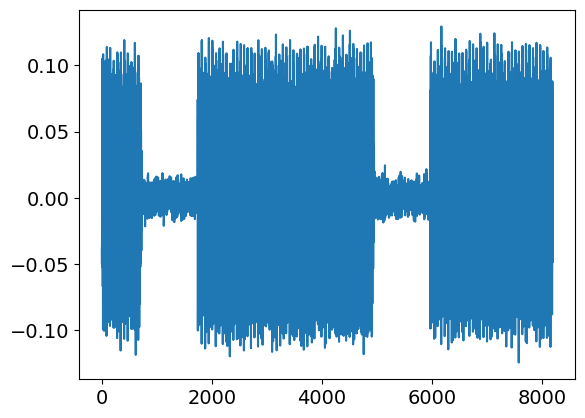

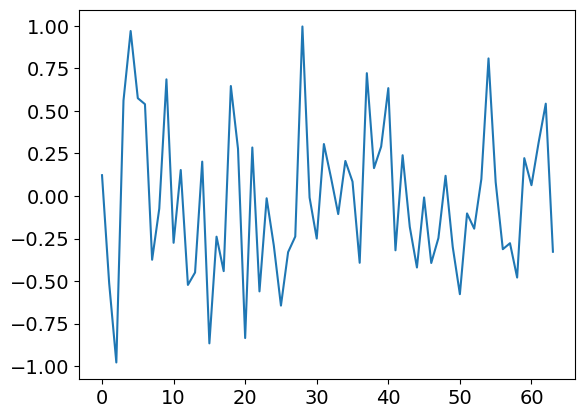

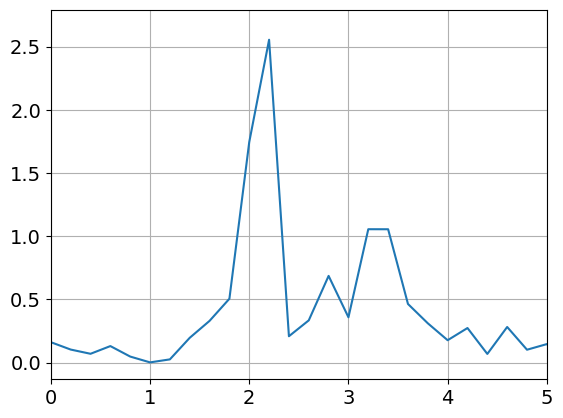

In [ ]:
plt.figure()
plt.plot(np.real(rx0))
plt.figure()
plt.plot(np.real(norm_ofdm_time['a']))


rx0 = np.asarray(rx0, dtype=np.complex64)
preamble = np.asarray( norm_ofdm_time['a'] , dtype=np.complex64)

median_corr = np.median(metric)
print("Median Correlation: " + str(median_corr))


# --- Complex matched filter correlation ---
kernel = np.conj(preamble[::-1])
xcorr_out = signal.fftconvolve(rx0, kernel, mode='valid')  # valid mode → only non-negative shifts
metric = np.abs(xcorr_out)
plt.figure()
delta = 0.2
plt.plot(np.arange(0, 6*64)*delta, metric[0:(6*64)])
plt.xlim(0,5)
plt.grid(True)


In [ ]:
def cross_correlation_max(rx0, preamble, preamble_scale=0.001):
    """
    Cross-correlate rx0 with a known preamble and plot:
      - RX real/imag with the detected preamble overlaid at the detected start index
      - Correlation magnitude (or NCC) vs. sample index (no negative lags)
    """

    rx0 = np.asarray(rx0, dtype=np.complex64)
    preamble = np.asarray(preamble, dtype=np.complex64)

    # --- Complex matched filter correlation ---
    kernel = np.conj(preamble[::-1])
    xcorr_out = signal.fftconvolve(rx0, kernel, mode='valid')  # valid mode → only non-negative shifts
    metric = np.abs(xcorr_out)

    median_corr = np.median(metric)
    print("Median Correlation: " + str(median_corr))

    # Return the index of the first peak of the correlation output
    # after a period of more than RR samples of noise. This is because when
    # we create the signal, we add 1024 samples of zeros before the packet.
    RR = 512
    delta = RR//16
    lag_index = 0
    max_index = len(rx0) - RR
    threshold = 4*median_corr
    noise_only = (np.max(metric[lag_index:lag_index+RR]) < threshold)
    lag_index += delta
    while (not noise_only) and lag_index < max_index:
        if np.max(metric[lag_index:lag_index+RR]) < threshold:
            noise_only = True
        lag_index += delta

    while noise_only and lag_index < max_index:
        if np.max(metric[lag_index:lag_index+RR]) > threshold:
            noise_only = False
            preamble_start = np.argmax(metric[lag_index:lag_index+RR]) + lag_index
        lag_index += delta

    # Output the results, the preamble_start index and some plots to help us
    # make sure that the procedure worked correctly.
    print(f"Detected preamble at sample index {preamble_start}")
    # --- Plot the output so the user can validate that it is working ---
    fig, axes = plt.subplots(2, 1, figsize=(11, 6))
    # Top: RX signal with overlaid preamble
    axes[0].plot(np.real(rx0), label='Real RX Signal')
    axes[0].plot(np.imag(rx0), label='Imag RX Signal')
    overlay_x = np.arange(preamble_start, preamble_start + len(preamble))
    overlay_p = preamble * preamble_scale
    axes[0].plot(overlay_x, np.real(overlay_p), label='Preamble (real, scaled)')
    axes[0].plot(overlay_x, np.imag(overlay_p), label='Preamble (imag, scaled)', alpha=0.7)
    axes[0].set_xlim(preamble_start, preamble_start + len(preamble))
    axes[0].set_title("Received Signal with Detected Preamble Overlay")
    axes[0].legend(loc='upper right')
    # Bottom: correlation metric vs. index
    axes[1].plot(metric, label="|Cross-correlation|")
    axes[1].axvline(preamble_start, linestyle='--', color='r', label=f'Detected start = {preamble_start}')
    axes[1].set_xlabel("Sample index")
    axes[1].set_ylabel("|Cross-correlation|")
    axes[1].legend(loc='upper right')
    axes[1].set_title(f"Cross-Correlation")
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

    # Plot metric within 100 samples around preamble_start
    plt.figure()
    plt.plot(np.arange(-64, 2*64+1)/64, metric[preamble_start-64:preamble_start+2*64+1])
    plt.grid(True)
    plt.show()
    return preamble_start


preamble_start = cross_correlation_max(rx0, norm_ofdm_time['a'], preamble_scale=0.0002)

Median Correlation: 0.10834947


UnboundLocalError: cannot access local variable 'preamble_start' where it is not associated with a value

We can estimate the complex (magnitude, angle) gain that each pilot subcarrier gets multiplied by, because we know what the original complex amplitude that was sent in the pilot subcarrier (`pilotValues`). This code calls those pilot subcarrier gains as `Hp`. We consider this full channel estimation because all subcarriers, except for the guard bands, are pilot channels.

This section implements estimating the channel gain by dividing the measured (received) pilot value by the pilot value that was known to be sent.

In [ ]:
def Channel_Estimation(signal, pilotValues):
    """
    Estimate the per-subcarrier channel H[k] for ONE OFDM symbol using pilots only.
    Strategy:
      1. Pull out the complex amplitude in the pilot subcarriers.
      2. Divide by Xp, the known pilot symbol value that was transmitted.
      3. Perform interpolation to estimate the channel at the data subcarriers.
         (Do linear interpolation on the log magnitude and on phase, separately)

    """
    eps = 1e-13  # small number to prevent divide-by-zero / log(0)

    # Pull out the complex amplitude in the pilot subcarriers.
    # Call your output `Yp`
    ### YOUR CODE HERE
    Yp = signal[pilotCarriers]

    # Divide by Xp, the known pilot symbol value that was transmitted
    # Make sure you don't divide by zero!  Call the output `Hp`
    ### YOUR CODE HERE
    Xp = pilotValues
    Hp = Yp / (Xp + eps)

    return Hp

In [ ]:
# Calculate the start index of the DATA part of the packet. Then copy `mess_length`
# samples, starting from that start index, into `data_signal`.
data_start = preamble_start
packet_len = FFT_size * repetitions
data_signal = rx0[data_start: data_start + packet_len]

# Process each symbol (which is `FFT_size` samples).
# Remember `FFT_size` is the total symbol length including the part that will
# have an FFT taken, and the cyclic prefix which will be dropped.
H_est = np.zeros((repetitions, pilots)) + 1j*np.zeros((repetitions, pilots))
for i in range(len(data_signal)//(FFT_size)):

    # Pick out the next `FFT_size` of samples from `data_signal`,
    # and call it `data_cp`.
    symbol_i = data_signal[i*(FFT_size):(i+1)*(FFT_size)]
    OFDM_freq = np.fft.fft(symbol_i, n=FFT_size)

    # Estimate the complex channel gain coefficients, using the pilot subcarriers.
    temp = Channel_Estimation(OFDM_freq, pilotValues) # estimate the channel

    # do the reverse of the FFT shift, because they arrive in temp out of order.
    H_est[i, 0:pilots//2] = temp[pilots//2:]
    H_est[i, pilots//2:] = temp[0:pilots//2]

# Make the filename include the experiment datetime, the TX, RX, and repnum.
plotname_str = datestr + "_" + txloc + "_" + rxloc + "_rep" + str(repNum)

# Plot the 2d H_est as a 3d plot
plt.figure()
plt.imshow(np.abs(H_est), interpolation='None', extent=[-pilots//2,pilots//2,repetitions,0])
plt.xlabel("Pilot subcarrier #")
plt.ylabel("Repetition #")
plt.colorbar()
plt.savefig("H_est_abs_" + plotname_str + ".pdf")

# Plot the 2d H_est as a 3d plot
plt.figure()
plt.imshow(np.angle(H_est), interpolation='None', extent=[-pilots//2,pilots//2,repetitions,0])
plt.xlabel("Pilot subcarrier #")
plt.ylabel("Repetition #")
plt.colorbar()
plt.savefig("H_est_angle_" + plotname_str + ".pdf")


In [ ]:
avg_H = np.mean(H_est, axis=0)
plt.figure()
plt.plot(range(-pilots//2,pilots//2), 20*np.log10(np.abs(avg_H)), 'r.:')
plt.xlabel("Pilot subcarrier #")
plt.xlim(-pilots//2,pilots//2)
plt.ylabel("Channel Gain (dB)")
plt.grid(True)
plt.savefig("H_avg_dB_" + plotname_str + ".pdf")

CIR = np.fft.fftshift(np.fft.fft(avg_H))
bandwidth = .500 # MHz
delta_t = 1/bandwidth # microseconds
tau = np.arange(-pilots//2,pilots//2) * delta_t
plt.figure()
plt.plot(tau, 20*np.log10(np.abs(CIR)), 'r.:')
plt.xlabel("Delay (us)")
plt.xlim((delta_t*(-pilots//2),delta_t*(pilots//2)))
plt.ylabel("CIR")
plt.grid(True)
plt.savefig("CIR_dB_" + plotname_str + ".pdf")

plt.figure()
maxlim = max(max(np.real(avg_H)), max(np.imag(avg_H)))
plt.plot(np.real(avg_H), np.imag(avg_H), 'r.:')
plt.text(np.real(avg_H[0]), np.imag(avg_H[0]), '0')
plt.text(np.real(avg_H[-1]), np.imag(avg_H[-1]), str(pilots-1))
plt.xlim(-maxlim,maxlim)
plt.ylim(-maxlim,maxlim)
plt.gca().set_aspect('equal')
plt.xlabel("Real part of channel gain")
plt.ylabel("Imag part of channel gain")
plt.grid(True)
plt.savefig("H_polar_" + plotname_str + ".pdf")
